# USAspending Public Buildings Service EDA

This notebook examines FY2024 GSA Public Buildings Service contract transactions.
FY2024 is the development period used to understand source behavior and design later features.
FY2025 remains sealed as a temporal holdout and is not profiled or visualized here.
Naturally unusual records are not labeled as defects without supporting evidence.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from datalens.analysis.eda import duplicate_summary, join_quality, profile_table
from datalens.paths import MANIFEST_DIR, PROCESSED_DATA_DIR

sns.set_theme(style="whitegrid")

transactions = pd.read_parquet(PROCESSED_DATA_DIR / "fy2024" / "transactions.parquet")
vendors = pd.read_parquet(PROCESSED_DATA_DIR / "fy2024" / "vendors.parquet")
holdout_manifest = json.loads(
    (MANIFEST_DIR / "prepared_pbs_fy2025.json").read_text(encoding="utf-8")
)

## Shape, grain, and relationships

A transaction record is one USAspending contract action identified by `contract_transaction_unique_key`.
A vendor record is the latest observed representation of one recipient UEI, with DUNS retained only as a legacy fallback.
Each transaction belongs to exactly one derived vendor through `vendor_id`.
Only FY2025 manifest metadata is shown to confirm that the holdout exists without inspecting its values.

In [2]:
display(
    pd.DataFrame(
        [
            {
                "period": "FY2024 development",
                "transaction_rows": len(transactions),
                "transaction_columns": len(transactions.columns),
                "vendor_rows": len(vendors),
                "vendor_columns": len(vendors.columns),
            },
            {
                "period": "FY2025 sealed holdout metadata",
                "transaction_rows": holdout_manifest["transaction_rows"],
                "transaction_columns": len(holdout_manifest["transaction_columns"]),
                "vendor_rows": holdout_manifest["vendor_rows"],
                "vendor_columns": len(holdout_manifest["vendor_columns"]),
            },
        ]
    )
)

print(
    "FY2024 transaction keys:",
    duplicate_summary(transactions, key="contract_transaction_unique_key"),
)
print("FY2024 vendor keys:", duplicate_summary(vendors, key="vendor_id"))
print("FY2024 join quality:", join_quality(vendors, transactions))

,period,transaction_rows,transaction_columns,vendor_rows,vendor_columns
0,FY2024 development,22064,78,1785,22
1,FY2025 sealed holdout metadata,19671,78,1652,22


FY2024 transaction keys: {'rows': 22064, 'exact_duplicate_rows': 0, 'duplicate_key_rows': 0, 'duplicate_key_values': 0, 'missing_key_rows': 0}
FY2024 vendor keys: {'rows': 1785, 'exact_duplicate_rows': 0, 'duplicate_key_rows': 0, 'duplicate_key_values': 0, 'missing_key_rows': 0}
FY2024 join quality: {'transaction_rows': 22064, 'vendor_rows': 1785, 'missing_vendor_key_rows': 0, 'unmatched_vendor_key_rows': 0, 'matched_transaction_rows': 22064, 'match_rate_percent': 100.0}


## Field types and missingness

The profile distinguishes storage types from likely semantic types.
Missing values are interpreted in context because fields such as parent award, set-aside, and action type are not required for every action.

,field,dtype,semantic_type,missing_count,missing_percent,unique_count
0,recipient_duns,string,categorical,22064,100.000,0
1,recipient_parent_duns,string,categorical,22064,100.000,0
2,recipient_doing_business_as_name,string,categorical,21936,99.420,39
3,recipient_address_line_2,string,categorical,18750,84.980,169
4,type_of_set_aside,string,categorical,17071,77.370,11
5,type_of_set_aside_code,string,identifier,17071,77.370,11
6,number_of_offers_received,Int64,numeric,10256,46.483,38
7,action_type,string,categorical,8843,40.079,16
8,action_type_code,string,identifier,8843,40.079,16
9,solicitation_date,"datetime64[ns, UTC]",date,8137,36.879,1225


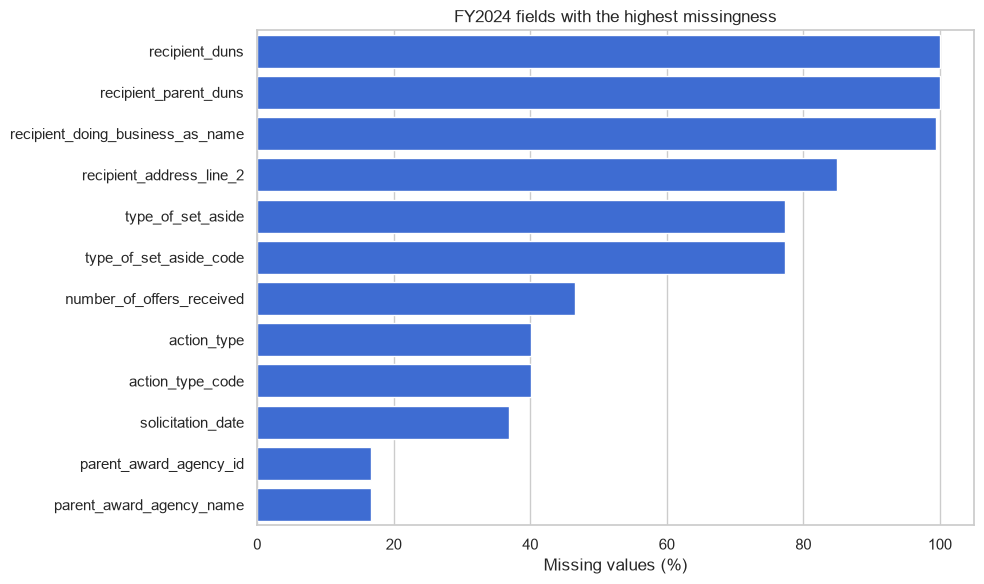

In [3]:
profile = profile_table(transactions)
display(profile.head(20))

missing_plot = profile.nlargest(12, "missing_percent")
plt.figure(figsize=(10, 6))
sns.barplot(data=missing_plot, y="field", x="missing_percent", color="#2563eb")
plt.title("FY2024 fields with the highest missingness")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Numeric and categorical distributions

Federal action obligations include positive obligations, zero-dollar administrative actions, and negative deobligations.
A symmetric logarithmic scale preserves all three operationally valid regions.

count           22064.0
mean      180565.479563
std      4347782.469042
min         -57432741.0
1%          -73966.2112
5%           -3319.5715
25%                 0.0
50%             6033.74
75%            34409.97
95%          449072.372
99%        2759036.0313
max         523650000.0
Name: federal_action_obligation, dtype: Float64

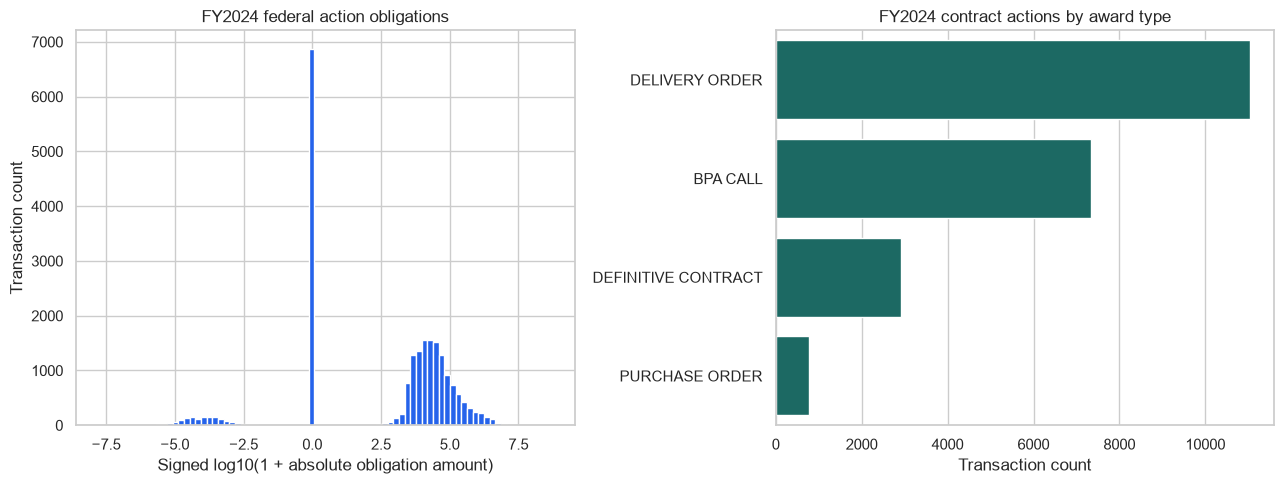

In [4]:
display(
    transactions["federal_action_obligation"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

signed_log_obligation = transactions["federal_action_obligation"].apply(
    lambda value: 0 if value == 0 else (1 if value > 0 else -1) * np.log10(1 + abs(value))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(signed_log_obligation, bins=80, color="#2563eb")
axes[0].set_title("FY2024 federal action obligations")
axes[0].set_xlabel("Signed log10(1 + absolute obligation amount)")
axes[0].set_ylabel("Transaction count")

award_types = (
    transactions["award_type"]
    .value_counts()
    .rename_axis("award_type")
    .reset_index(name="transactions")
)
sns.barplot(data=award_types, y="award_type", x="transactions", color="#0f766e", ax=axes[1])
axes[1].set_title("FY2024 contract actions by award type")
axes[1].set_xlabel("Transaction count")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

## Vendor concentration and development-period behavior

Vendor activity is strongly concentrated, so record-level evaluation alone could overstate performance on high-volume recipients.
Monthly development-period volume also shows whether seasonal structure should be represented in later features.

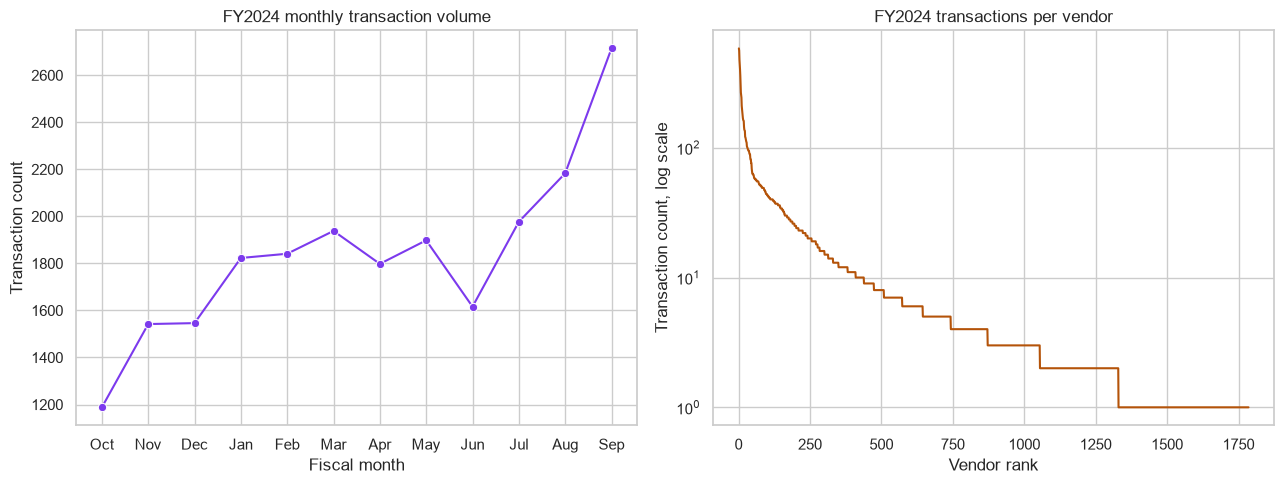

0.00      1.00
0.50      3.00
0.90     28.00
0.95     47.00
0.99    147.56
1.00    582.00
Name: source_transaction_count, dtype: float64

In [5]:
monthly = (
    transactions.assign(fiscal_month=((transactions["action_date"].dt.month - 10) % 12) + 1)
    .groupby("fiscal_month")
    .size()
    .rename("transactions")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(
    data=monthly,
    x="fiscal_month",
    y="transactions",
    marker="o",
    color="#7c3aed",
    ax=axes[0],
)
axes[0].set_title("FY2024 monthly transaction volume")
axes[0].set_xlabel("Fiscal month")
axes[0].set_xticks(
    range(1, 13),
    ["Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep"],
)
axes[0].set_ylabel("Transaction count")

vendor_volume = vendors["source_transaction_count"].sort_values(ascending=False)
axes[1].plot(range(1, len(vendor_volume) + 1), vendor_volume.to_numpy(), color="#b45309")
axes[1].set_yscale("log")
axes[1].set_title("FY2024 transactions per vendor")
axes[1].set_xlabel("Vendor rank")
axes[1].set_ylabel("Transaction count, log scale")
plt.tight_layout()
plt.show()

display(vendor_volume.quantile([0, 0.5, 0.9, 0.95, 0.99, 1]))

## Candidate quality checks and limitations

- FY2024 transaction keys and derived vendor keys are unique.
- Every FY2024 transaction joins to a vendor through UEI.
- DUNS is entirely absent, which is expected after the federal transition to UEI and should not be treated as a defect.
- Negative obligations are valid deobligations and zero-dollar actions are often administrative, so sign alone is not a defect rule.
- Parent award fields are structurally absent for standalone awards.
- Action type and offer count missingness depend on action and competition context.
- One FY2024 record has a current performance end date before its performance start date and merits review, but source unusualness is not ground truth.
- Vendor addresses vary across transactions for hundreds of vendors, which could reflect correction, relocation, formatting, or genuine inconsistency.
- The development dataset covers one GSA sub-agency and does not represent all federal procurement or private-enterprise vendor master data.
- USAspending can correct historical records, so acquisition manifests and hashes are required for reproducibility.
- FY2025 values remain uninspected in this notebook to protect the temporal evaluation boundary.

Open questions for feature engineering are whether missingness should be conditional on award context, which date relationships are universally invalid, and how vendor address consistency should distinguish movement from contradictory simultaneous values.